In [1]:
# import libraries
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [2]:
# load datasets
sst_ds = xr.open_dataset('../data/sst.mon.mean_OISSTv2p1_IndoPacific_lon20E-290E_lat30S-30N_198109-202607.nc')
pr_ds = xr.open_dataset('../data/mswep_pr_daily_brunei_1980_2025.nc')

In [3]:
# extract sst variable from the dataset
sst = sst_ds['sst']

# extract pr variable from the dataset
pr = pr_ds['precipitation']

In [4]:
# split data to training and testing sets
sst_train = sst.sel(time=slice('1981-09-01', '2020-12-31'))
sst_test = sst.sel(time=slice('2021-01-01', '2026-07-31'))

pr_train = pr.sel(time=slice('1981-09-01', '2020-12-31'))
pr_test = pr.sel(time=slice('2021-01-01', '2025-12-31'))

## SST

### Test Datset Preparation

In [5]:
# calculate monthly mean
sst_train_mean = sst_train.groupby('time.month').mean('time')

In [6]:
# create SST anomalies
sst_train_anom = sst_train.groupby('time.month') - sst_train_mean

In [7]:
# flatten to 2D matrix for SVD
X_train_full = sst_train_anom.values.reshape(len(sst_train_anom.time), -1)
X_train_full.shape

(472, 259200)

In [8]:
# create ocean mask
mask = np.isfinite(X_train_full).all(axis=0)

X_train = X_train_full[:, mask]

In [9]:
# apply latitude weighting
weights = np.sqrt(np.cos(np.deg2rad(sst_train_anom.lat)))

W = np.repeat(weights.values[:, None], len(sst_train_anom.lon), axis=1).ravel()

W = W[mask]

X_train_w = X_train * W

In [10]:
# perform SVD
U_train, s_train, VT_train = np.linalg.svd(X_train_w, full_matrices=False)

In [11]:
# get EOFs
EOFs = VT_train

# get PCs
PCs_train = U_train * s_train

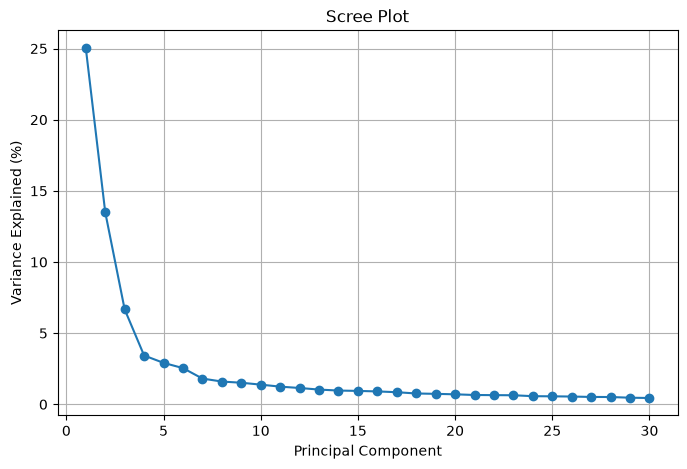

In [12]:
var_exp = (s_train**2) / np.sum(s_train**2)

# scree plot
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, 31), var_exp[:30]*100, marker='o')

plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.title('Scree Plot')
plt.grid(True)

plt.show()

C:\Users\Nitro\AppData\Local\Temp\ipykernel_19368\407257008.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


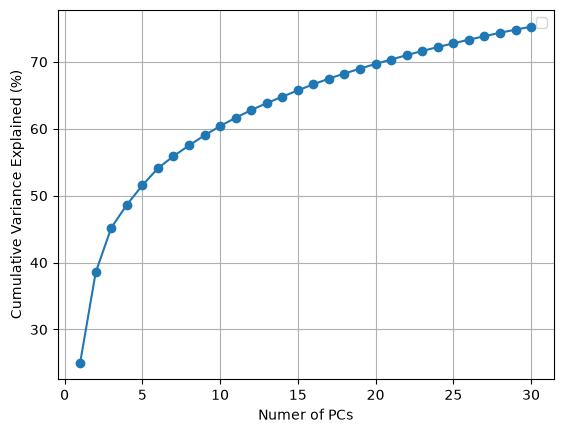

In [13]:
cum_var = np.cumsum(var_exp)

# cumulative variance plot
plt.Figure(figsize=(8, 5))
plt.plot(np.arange(1, 31), cum_var[:30]*100, marker='o')

#plt.axhline(y=80, color='r', linestyle='--', label='80% Variance Explained')

plt.xlabel('Numer of PCs')
plt.ylabel('Cumulative Variance Explained (%)')

plt.legend()
plt.grid(True)

plt.show()

### Test Dataset Preparation

In [14]:
# create SST anomalies
# use mean from train data
sst_test_anom = sst_test.groupby('time.month') - sst_train_mean

In [15]:
# convert to matrix for SVD
X_test = sst_test_anom.values.reshape(len(sst_test_anom.time), -1)
X_test.shape

(67, 259200)

In [16]:
# apply ocean mask
X_test = X_test[:, mask]

In [17]:
# apply latitude weighting
X_test_w = X_test * W

In [20]:
# get principal components
PCs_test = X_test_w @ VT_train.T

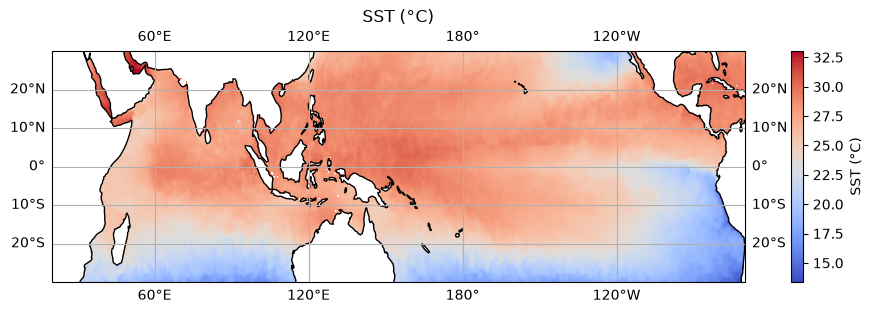

In [ ]:
fig = plt.figure(figsize=(12, 3))

ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

sst.isel(time=0).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    cbar_kwargs={'label': 'SST (°C)'}
)

ax.coastlines()
ax.gridlines(draw_labels=True)

ax.set_aspect(aspect=1.5)

plt.title('SST (°C)')
plt.show()

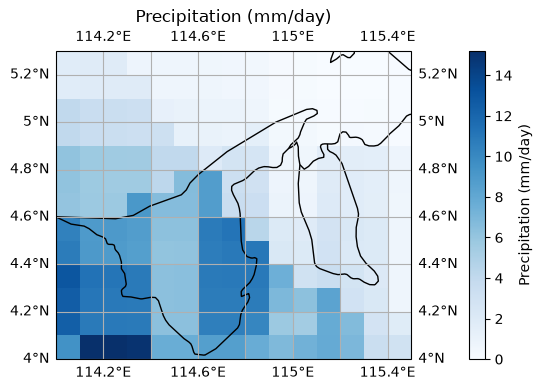

In [ ]:
import cartopy.feature as cfeature

plt.figure(figsize=(15, 4))

ax = plt.axes(projection=ccrs.PlateCarree())

pr.isel(time=1).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='Blues',
    cbar_kwargs={'label': 'Precipitation (mm/day)'}
)

ax.add_feature(cfeature.BORDERS)
ax.coastlines()
ax.gridlines(draw_labels=True)

plt.title('Precipitation (mm/day)')
plt.show()

